<div align="center">

# Preprocessing

</div>

# 1. Highpass fitler + Notch filter

# TUDO

> Filters and turns files into HDF5

In [9]:
import os
import re
import h5py
import mne
import numpy as np


# =========================================================
# Parse CHB-MIT summary.txt
# =========================================================
def parse_chbmit_summary(summary_path):

    seizures_dict = {}

    with open(summary_path, "r", encoding="latin1") as f:
        text = f.read()

    blocks = text.split("File Name:")

    for block in blocks:

        if ".edf" not in block:
            continue

        # ---------------------------------------------
        # EDF filename extraction
        # ---------------------------------------------
        file_match = re.search(
            r"(chb\d+[a-z]?_\d+\+?\.edf)",
            block
        )

        if not file_match:
            file_match = re.search(
                r"(chb\d+[a-z]?_\d+[^\s]*\.edf)",
                block
            )

        if not file_match:
            continue

        file_name = file_match.group(1)

        seizures = []

        # ---------------------------------------------
        # Numbered seizures
        # ---------------------------------------------
        starts_num = re.findall(
            r"Seizure\s*\d+\s*Start Time:\s*(\d+)",
            block
        )

        ends_num = re.findall(
            r"Seizure\s*\d+\s*End Time:\s*(\d+)",
            block
        )

        if len(starts_num) > 0 and len(ends_num) > 0:

            seizures = [
                (int(s), int(e))
                for s, e in zip(starts_num, ends_num)
            ]

        else:

            # ---------------------------------------------
            # Single seizure format
            # ---------------------------------------------
            start = re.search(
                r"Seizure Start Time:\s*(\d+)",
                block
            )

            end = re.search(
                r"Seizure End Time:\s*(\d+)",
                block
            )

            if start and end:

                seizures = [
                    (
                        int(start.group(1)),
                        int(end.group(1))
                    )
                ]

        seizures_dict[file_name] = seizures

    return seizures_dict


# =========================================================
# EDF -> FILTERED HDF5
# =========================================================
def edf_to_filtered_h5(
    edf_path,
    h5_path,
    seizures_sec,
    highpass=0.5,
    notch=60
):

    # ---------------------------------------------
    # Load EDF
    # ---------------------------------------------
    raw = mne.io.read_raw_edf(
        edf_path,
        preload=True,
        verbose=False
    )

    raw.rename_channels(lambda x: x.strip())

    fs = float(raw.info["sfreq"])
    ch_names = np.array(raw.ch_names, dtype="S")

    # ---------------------------------------------
    # Filtering
    # ---------------------------------------------
    raw.filter(
        l_freq=highpass,
        h_freq=None,
        method="iir",
        iir_params=dict(order=4, ftype="butter"),
        phase="zero",
        verbose=False
    )

    raw.notch_filter(
        freqs=notch,
        method="iir",
        phase="zero",
        verbose=False
    )

    # ---------------------------------------------
    # Extract filtered signal
    # ---------------------------------------------
    data = raw.get_data().astype(np.float32)

    # ---------------------------------------------
    # Convert seizures sec -> samples
    # ---------------------------------------------
    seizures_samples = np.array(
        [
            (int(s * fs), int(e * fs))
            for s, e in seizures_sec
        ],
        dtype=np.int64
    )

    if seizures_samples.size == 0:
        seizures_samples = np.zeros((0, 2), dtype=np.int64)

    # ---------------------------------------------
    # Create output directory
    # ---------------------------------------------
    os.makedirs(
        os.path.dirname(h5_path),
        exist_ok=True
    )

    # ---------------------------------------------
    # Save HDF5
    # ---------------------------------------------
    with h5py.File(h5_path, "w") as f:

        f.create_dataset(
            "signals",
            data=data,
            dtype=np.float32,
            compression="gzip",
            compression_opts=4,
            shuffle=False,
            chunks=(data.shape[0], 1024)
        )

        f.create_dataset(
            "sampling_rate",
            data=fs
        )

        f.create_dataset(
            "channel_names",
            data=ch_names
        )

        f.create_dataset(
            "seizure_intervals",
            data=seizures_samples
        )

    print(f"✓ Saved → {h5_path}")


# =========================================================
# Batch processing
# =========================================================
def convert_dataset_filtered(
    seizure_map,
    DATASET_PATH,
    OUTPUT_PATH
):

    for file_name, seizures_sec in seizure_map.items():

        edf_path = os.path.join(
            DATASET_PATH,
            file_name
        )

        if not os.path.exists(edf_path):
            print(f"Missing: {edf_path}")
            continue

        h5_path = os.path.join(
            OUTPUT_PATH,
            file_name.replace(".edf", ".h5")
        )

        try:

            edf_to_filtered_h5(
                edf_path=edf_path,
                h5_path=h5_path,
                seizures_sec=seizures_sec
            )

        except Exception as e:

            print(f"✗ Error {file_name}: {e}")

In [32]:
nums = [f"{i:02d}" for i in range(1, 2)]

for numero in nums:

    # -------------------------------------------------
    # Summary file
    # -------------------------------------------------
    summary_path = f"../Dataset/chb{numero}/chb{numero}-summary.txt"

    seizure_map = parse_chbmit_summary(summary_path)

    print(f"\nProcessing patient chb{numero}")

    # -------------------------------------------------
    # Input / output folders
    # -------------------------------------------------
    DATASET_PATH = f"../Dataset/chb{numero}"
    OUTPUT_PATH = f"../Dataset_hdf5_filtered/chb{numero}"

    os.makedirs(OUTPUT_PATH, exist_ok=True)

    # -------------------------------------------------
    # Run filtered conversion
    # -------------------------------------------------
    convert_dataset_filtered(
        seizure_map=seizure_map,
        DATASET_PATH=DATASET_PATH,
        OUTPUT_PATH=OUTPUT_PATH
    )

C:\Users\ritaw\AppData\Local\Temp\ipykernel_19804\1109488660.py:24: RuntimeWarning: Channel names are not unique, found duplicates for: {'T8-P8'}. Applying running numbers for duplicates.
  raw = mne.io.read_raw_edf(


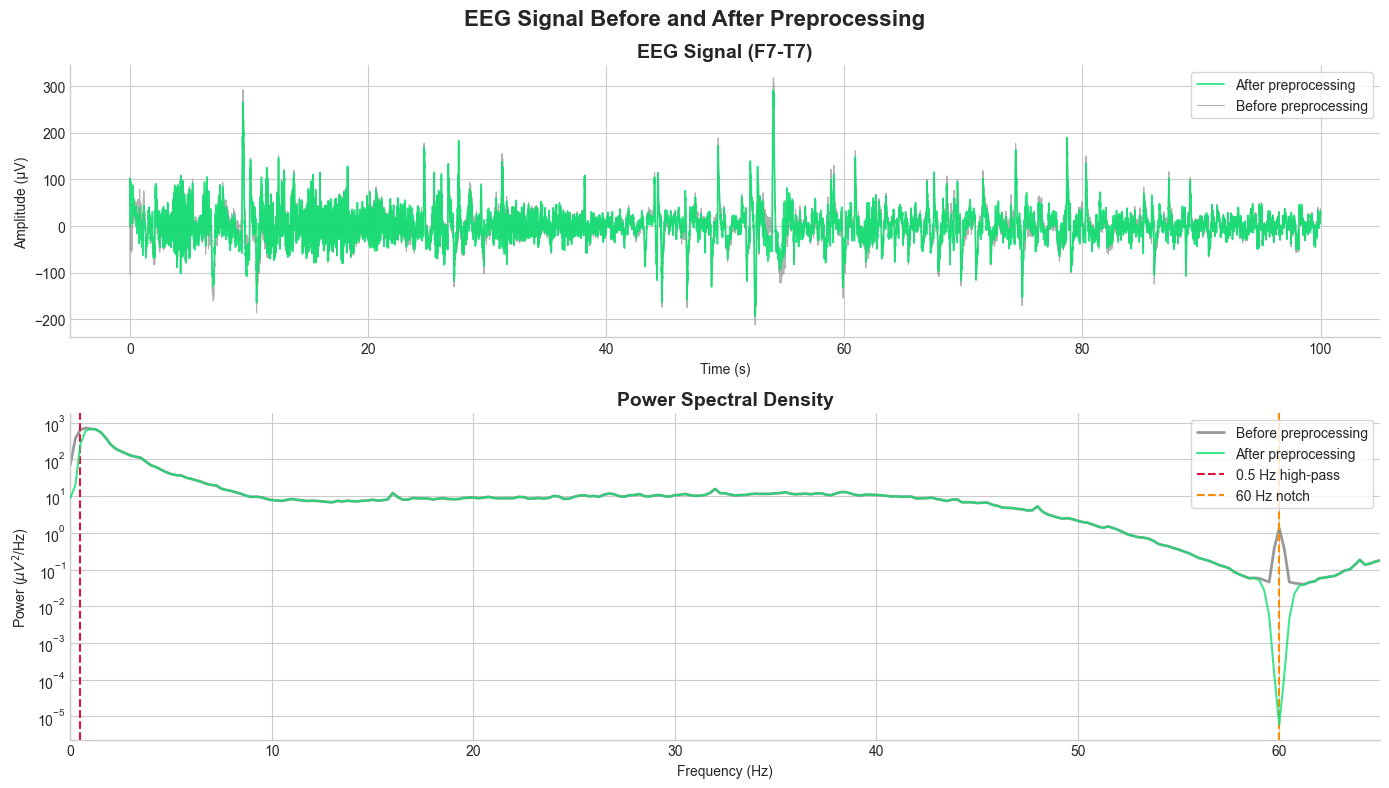

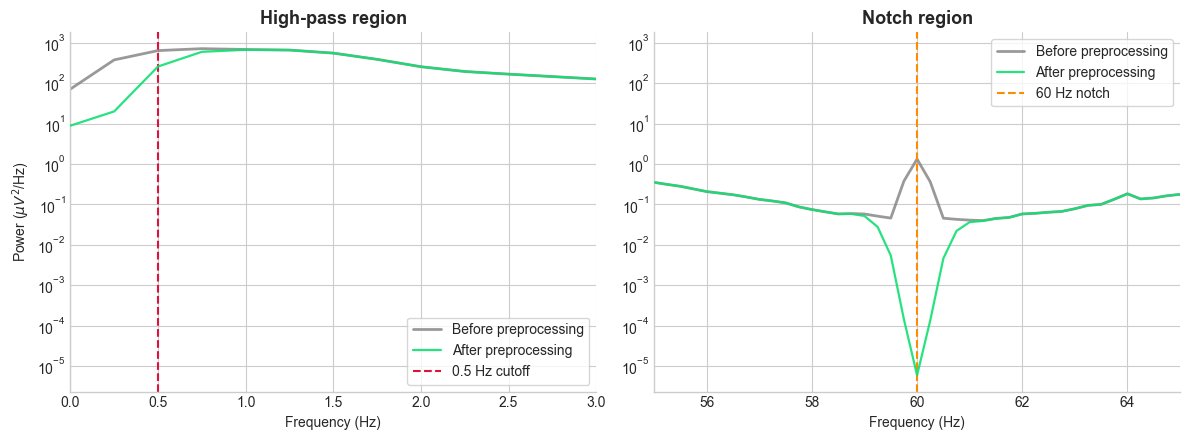

In [31]:
import numpy as np
import h5py
import mne
import matplotlib.pyplot as plt
from scipy.signal import welch

# ----------------------------------------------------
# HDF5 loader
# ----------------------------------------------------
def load_h5(path):
    with h5py.File(path, "r") as f:
        signals = f["signals"][:]
        fs = f["sampling_rate"][()]
        ch_names = f["channel_names"][:]
    ch_names = [
        c.decode() if isinstance(c, (bytes, bytearray)) else c
        for c in ch_names
    ]
    return signals, fs, ch_names

# ----------------------------------------------------
# Load original EDF
# ----------------------------------------------------
raw = mne.io.read_raw_edf(
    "../Dataset/chb01/chb01_01.edf",
    preload=True,
    verbose=False
)
channel = "F7-T7"
idx = raw.ch_names.index(channel)
signal_before = raw.get_data()[idx]
fs_before = raw.info["sfreq"]

# ----------------------------------------------------
# Load processed HDF5
# ----------------------------------------------------
signals, fs_after, ch_names = load_h5("../Data/chb01_01.h5")
idx = ch_names.index(channel)
signal_after = signals[idx]

# ----------------------------------------------------
# Convert V -> uV
# ----------------------------------------------------
signal_before = signal_before * 1e6
signal_after = signal_after * 1e6

# ----------------------------------------------------
# Time window (10s for legibility)
# ----------------------------------------------------
window_sec = 100
n = int(window_sec * fs_before)
t = np.arange(n) / fs_before

# ----------------------------------------------------
# PSD
# ----------------------------------------------------
freq_before, psd_before = welch(signal_before, fs=fs_before, nperseg=int(fs_before * 4))
freq_after, psd_after = welch(signal_after, fs=fs_after, nperseg=int(fs_after * 4))

# ======================================================
# FIGURE 1: Main figure — time domain + full-range PSD
# ======================================================
plt.style.use("seaborn-v0_8-whitegrid")
fig, axes = plt.subplots(2, 1, figsize=(14, 8), gridspec_kw={"height_ratios": [1, 1.2]})

# ---------------- Time domain ----------------
axes[0].plot(t, signal_after[:n], color="#0fe071", lw=1.2, alpha=0.9,
             label="After preprocessing", zorder=3)
axes[0].plot(t, signal_before[:n], color="gray", lw=0.8, alpha=0.6,
             label="Before preprocessing", zorder=2)
axes[0].set_title(f"EEG Signal ({channel})", fontsize=14, fontweight="bold")
axes[0].set_xlabel("Time (s)")
axes[0].set_ylabel("Amplitude (µV)")
axes[0].legend(frameon=True, loc="upper right")
axes[0].spines["top"].set_visible(False)
axes[0].spines["right"].set_visible(False)

# ---------------- PSD (full range) ----------------
axes[1].semilogy(freq_before, psd_before, color="gray", lw=2.0, alpha=0.8,
                  label="Before preprocessing", zorder=2)
axes[1].semilogy(freq_after, psd_after, color="#0fe071", lw=1.5, alpha=0.8,
                  label="After preprocessing", zorder=3)
axes[1].axvline(0.5, color="crimson", linestyle="--", linewidth=1.5, label="0.5 Hz high-pass")
axes[1].axvline(60, color="darkorange", linestyle="--", linewidth=1.5, label="60 Hz notch")
axes[1].set_xlim(0, 65)
axes[1].set_title("Power Spectral Density", fontsize=14, fontweight="bold")
axes[1].set_xlabel("Frequency (Hz)")
axes[1].set_ylabel(r"Power ($\mu V^2$/Hz)")
axes[1].legend(frameon=True, loc="upper right")
axes[1].spines["top"].set_visible(False)
axes[1].spines["right"].set_visible(False)

fig.suptitle("EEG Signal Before and After Preprocessing", fontsize=16, fontweight="bold", y=0.98)
plt.tight_layout()
plt.savefig("preprocessing_comparison.png", dpi=300, bbox_inches="tight")
plt.show()

# ======================================================
# FIGURE 2: Zoomed pair — high-pass region + notch region
# ======================================================
fig2, axes2 = plt.subplots(1, 2, figsize=(12, 4.5))

# ---------------- High-pass zoom (0-3 Hz) ----------------
axes2[0].semilogy(freq_before, psd_before, color="gray", lw=2.0, alpha=0.8,
                   label="Before preprocessing", zorder=2)
axes2[0].semilogy(freq_after, psd_after, color="#0fe071", lw=1.6, alpha=0.9,
                   label="After preprocessing", zorder=3)
axes2[0].axvline(0.5, color="crimson", linestyle="--", linewidth=1.5, label="0.5 Hz cutoff")
axes2[0].set_xlim(0, 3)
axes2[0].set_title("High-pass region", fontsize=13, fontweight="bold")
axes2[0].set_xlabel("Frequency (Hz)")
axes2[0].set_ylabel(r"Power ($\mu V^2$/Hz)")
axes2[0].legend(frameon=True)
axes2[0].spines["top"].set_visible(False)
axes2[0].spines["right"].set_visible(False)

# ---------------- Notch zoom (55-65 Hz) ----------------
axes2[1].semilogy(freq_before, psd_before, color="gray", lw=2.0, alpha=0.8,
                   label="Before preprocessing", zorder=2)
axes2[1].semilogy(freq_after, psd_after, color="#0fe071", lw=1.6, alpha=0.9,
                   label="After preprocessing", zorder=3)
axes2[1].axvline(60, color="darkorange", linestyle="--", linewidth=1.5, label="60 Hz notch")
axes2[1].set_xlim(55, 65)
axes2[1].set_title("Notch region", fontsize=13, fontweight="bold")
axes2[1].set_xlabel("Frequency (Hz)")
axes2[1].legend(frameon=True)
axes2[1].spines["top"].set_visible(False)
axes2[1].spines["right"].set_visible(False)

plt.tight_layout()
plt.savefig("psd_zoomed_pair.png", dpi=300, bbox_inches="tight")
plt.show()